In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [37]:
df = pd.read_csv("../preprocessed_data.csv")

df.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,y_yes
0,58,2143,5,261.0,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,False
1,44,29,5,151.0,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,False
2,33,2,5,76.0,1,-1,0,False,True,False,...,False,False,True,False,False,False,False,False,True,False
3,47,1506,5,92.0,1,-1,0,True,False,False,...,False,False,True,False,False,False,False,False,True,False
4,33,1,5,198.0,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,False


In [38]:
df.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes',
       'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'y_yes'],
      dtype='object')

In [ ]:
#targwt column
X = df.drop('y_yes', axis=1)
y = df['y_yes']



In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [79]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [91]:
#creat model
model1 = SVC(kernel='rbf', C=1, gamma='scale')
model2 = SVC(kernel='rbf', C=10, gamma='auto') #rbf-curver(better for real data) #C = fitting(10 better fitting)
model3 = SVC(kernel='linear', C=1)

#Train SVM Model
model2.fit(X_train, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


TEST

In [92]:
#Predict
pred = model2.predict(X_test)

print(X_test)
print(pred)

[[-1.01451764 -0.00275198 -1.17168427 ... -0.20531944 -0.18106283
  -2.13846934]
 [ 0.80211049 -2.74146801  1.34057173 ... -0.20531944 -0.18106283
   0.46762419]
 [ 0.03721443 -0.55639759  0.6227843  ... -0.20531944 -0.18106283
   0.46762419]
 ...
 [ 1.08894651  0.74213156  0.26389059 ... -0.20531944 -0.18106283
   0.46762419]
 [-0.72768162 -1.24933996  0.02462811 ... -0.20531944 -0.18106283
   0.46762419]
 [ 0.22843844 -0.75825985  1.69946544 ... -0.20531944 -0.18106283
   0.46762419]]
[False False False ... False False False]


In [93]:
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9050265530443374


In [94]:
#Classification Report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       False       0.93      0.96      0.95      7215
        True       0.59      0.43      0.50       882

    accuracy                           0.91      8097
   macro avg       0.76      0.70      0.72      8097
weighted avg       0.90      0.91      0.90      8097



In [ ]:
#Confusion Matrix  - TN,FP FN,TP
print(confusion_matrix(y_test, pred))

[[7100  115]
 [ 641  241]]


The model performs well for the majority class (NO), but poorly for the minority class (YES), indicating class imbalance and difficulty in detecting positive cases

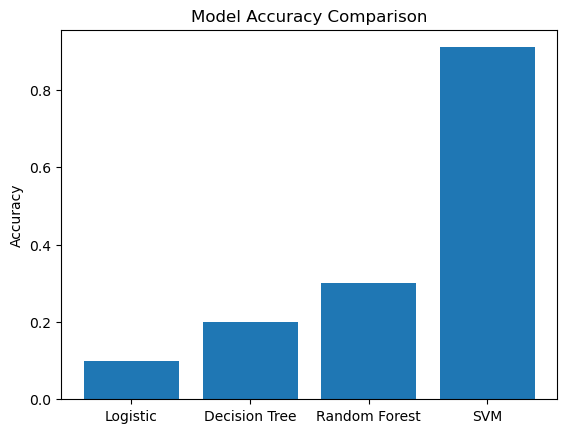

In [2]:
#Accuracy Comparison Chart
import matplotlib.pyplot as plt

models = ['Logistic', 'Decision Tree', 'Random Forest', 'SVM']
accuracy = [0.10, 0.20, 0.30, 0.91]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()